# Chapter 5 - Voronoi Diagrams

## Source Span

This notebook covers **Computational Geometry in C**, Chapter 5, printed pages 155-192: Voronoi applications, definitions and properties, Delaunay triangulations, construction algorithms, nearest-neighbor and largest-empty-circle applications, medial axes, paraboloid lifting to convex hulls, and the relationship with arrangements. The chapter connects three structures that have appeared separately: nearest-site regions, triangulations, and convex hulls.

A Voronoi cell is the set of points at least as close to one site as to every other site. That makes each cell an intersection of half-planes and therefore convex. A cell is unbounded precisely when its site lies on the convex hull of the site set. The Delaunay triangulation is the straight-line dual of the Voronoi diagram under nondegenerate assumptions: neighboring Voronoi cells correspond to Delaunay edges. The empty-circle theorem gives the practical test: two sites share a Delaunay edge exactly when there is an empty circle through them, and each Delaunay triangle has an empty circumcircle. The diagram's linear size comes from this planar duality.

The source span also emphasizes applications. Nearest-neighbor graphs and Euclidean minimum spanning trees sit inside the Delaunay triangulation. Largest empty circles occur at Voronoi vertices or boundary events. The medial axis of a polygon is a related nearest-boundary structure built from centers with multiple closest boundary points. Finally, lifting sites to the paraboloid `z=x^2+y^2` turns Delaunay triangles into lower convex-hull facets, while tangent planes and arrangements give another dual view.


## Visual Storyboard

1. **Voronoi/Delaunay overlay.** Plot nearest-site cells, Delaunay edges, and convex-hull sites; check bounded-cell logic and dual edge consistency.
2. **Empty-circle theorem.** Draw circumcircles for Delaunay triangles and verify no input site lies strictly inside them.
3. **Applications board.** Compute nearest-neighbor edges, Euclidean MST edges, and a largest empty circle candidate from Voronoi vertices.
4. **Medial-axis sketch.** Use a corridor-like polygon to show maximal-circle centers and the grassfire interpretation without copying source figures.
5. **Paraboloid lifting.** Lift sites to `z=x^2+y^2`, draw Delaunay triangles as lower-hull shadows, and check circumcenter/equidistance relations.
6. **Algorithm map.** Compare half-plane intersection, incremental, divide-and-conquer, Fortune sweep, hull lifting, and arrangement-envelope viewpoints.


## Library Routing

`scipy.spatial` supplies `Voronoi`, `Delaunay`, and `ConvexHull` so the notebook can focus on source-grounded interpretation rather than rebuilding robust predicates from scratch. The chapter's mathematical checks are still explicit: empty circumcircles, MST containment in Delaunay, nearest-neighbor containment in Delaunay, and paraboloid lifting. `networkx` handles MST and graph checks, while the book-local artifact helpers save every figure and table under the chapter artifact subtree.


In [1]:
# setup
from __future__ import annotations
import json, math, sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.spatial import ConvexHull, Delaunay, Voronoi, voronoi_plot_2d
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

BOOK_ROOT = Path.cwd()
while not ((BOOK_ROOT / "AGENTS.md").exists() and (BOOK_ROOT / "source_map.json").exists()):
    if BOOK_ROOT.parent == BOOK_ROOT:
        raise RuntimeError("Could not locate Computational-Geometry-in-C root")
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-05-voronoi-diagrams"
UNIT_TITLE = "Voronoi Diagrams"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

storyboard = [
    {"move": "Voronoi-Delaunay overlay", "visual": "voronoi-delaunay-overlay.png", "check": "delaunay_edges_match_voronoi_ridges"},
    {"move": "empty circumcircles", "visual": "empty-circle-checks.png", "check": "all_delaunay_circumcircles_empty"},
    {"move": "applications board", "visual": "nearest-mst-largest-empty-circle.png", "check": "mst_and_nearest_edges_are_delaunay"},
    {"move": "medial axis sketch", "visual": "medial-axis-maximal-circles.png", "check": "medial_centers_have_two_or_more_boundary_contacts"},
    {"move": "paraboloid lifting", "visual": "paraboloid-lifting-delaunay.png", "check": "lifted_triangles_have_empty_circles"},
]
routing_rows = [
    {"source_topic": "Voronoi cells and convex half-plane intersections", "artifact": "voronoi-delaunay-overlay.png", "code_cell": "Voronoi overlay"},
    {"source_topic": "Delaunay duality and empty-circle theorem", "artifact": "empty-circle-checks.png", "code_cell": "circumcircle checks"},
    {"source_topic": "nearest neighbor, MST, largest empty circle", "artifact": "nearest-mst-largest-empty-circle.png", "code_cell": "applications"},
    {"source_topic": "medial axis and maximal circles", "artifact": "medial-axis-maximal-circles.png", "code_cell": "medial axis"},
    {"source_topic": "paraboloid lifting and arrangement envelopes", "artifact": "paraboloid-lifting-delaunay.png", "code_cell": "lifting"},
]
storyboard_path = save_json({"unit": UNIT_TITLE, "source_span": "printed pages 155-192", "storyboard": storyboard}, CHECKS / "visual-storyboard.json")
routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
coverage_path = save_json({
    "unit": UNIT_TITLE,
    "source_span": {"printed_pages": "155-192", "pdf_pages": "164-201"},
    "covered_ideas": [
        "Voronoi applications: nearest facility, clustering, largest empty circle, path planning, growth models",
        "Voronoi cells as nearest-site half-plane intersections and boundedness via hull sites",
        "Delaunay triangulation as straight-line dual and empty-circle theorem",
        "construction approaches: half-plane intersection, incremental, divide-and-conquer, Fortune sweep",
        "nearest-neighbor graph, Euclidean MST, furthest-site and largest-empty-circle uses",
        "medial axis, maximal circles, and grassfire intuition",
        "paraboloid lifting to lower hull and tangent-plane arrangement view",
    ],
}, CHECKS / "source-coverage.json")
print(json.dumps({"artifact_root": str(ARTIFACT_ROOT), "storyboard_items": len(storyboard)}, indent=2))


{
  "artifact_root": "D:\\Geometry\\Computational-Geometry-in-C\\artifacts\\chapter-05-voronoi-diagrams",
  "storyboard_items": 5
}


## Voronoi Cells, Delaunay Duality, and Boundedness

The Voronoi diagram partitions the plane by nearest site. Its straight-line dual is the Delaunay triangulation: if two cells share an edge, the corresponding sites are connected. Hull sites have unbounded Voronoi regions, while interior sites have bounded regions. The plot below overlays all three pieces of information so the duality is visible rather than merely asserted.


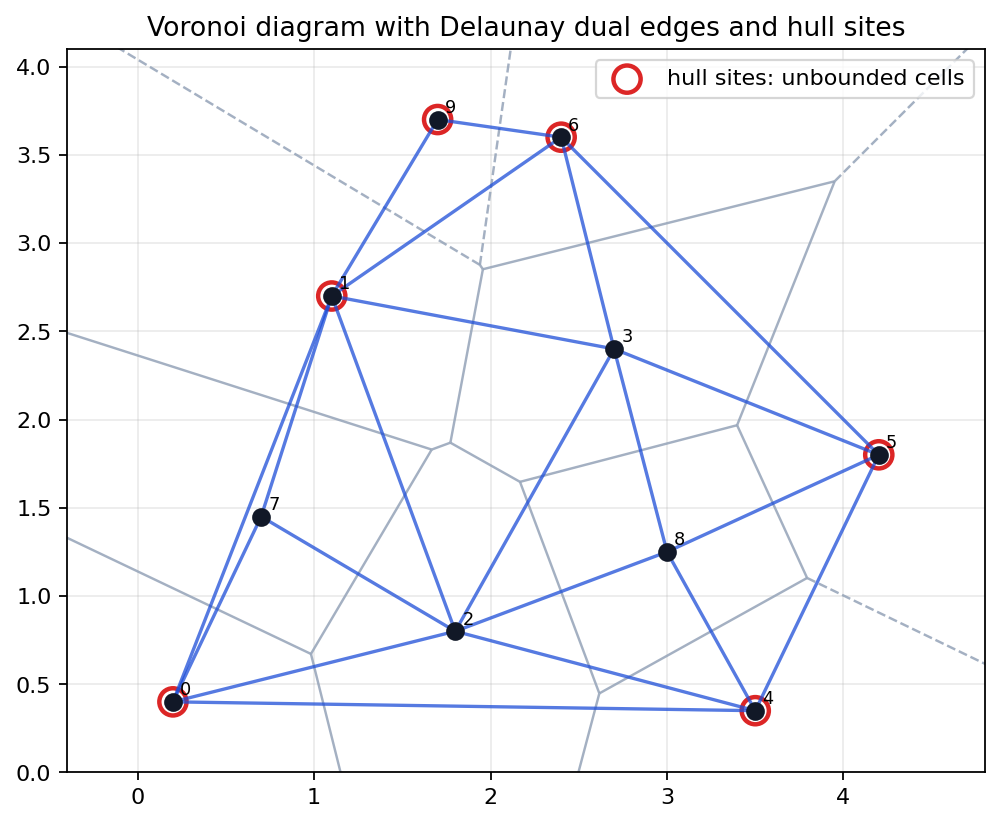

In [2]:
sites = np.array([
    [0.2, 0.4], [1.1, 2.7], [1.8, 0.8], [2.7, 2.4], [3.5, 0.35],
    [4.2, 1.8], [2.4, 3.6], [0.7, 1.45], [3.0, 1.25], [1.7, 3.7]
], float)
vor = Voronoi(sites)
delau = Delaunay(sites)
hull2 = ConvexHull(sites)
hull_sites = set(hull2.vertices.tolist())

def delaunay_edges(tri):
    return sorted({tuple(sorted((int(a), int(b)))) for simplex in tri.simplices for a, b in [(simplex[0], simplex[1]), (simplex[1], simplex[2]), (simplex[2], simplex[0])]})
D_edges = delaunay_edges(delau)
V_ridge_edges = sorted(tuple(sorted(map(int, pair))) for pair in vor.ridge_points)

fig, ax = plt.subplots(figsize=(7.4, 6.2))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors="#94a3b8", line_width=1.1, line_alpha=0.85, point_size=0)
for i, j in D_edges:
    ax.plot([sites[i,0], sites[j,0]], [sites[i,1], sites[j,1]], color="#1d4ed8", linewidth=1.5, alpha=0.75)
ax.scatter(sites[:,0], sites[:,1], color="#111827", s=55, zorder=5)
ax.scatter(sites[list(hull_sites),0], sites[list(hull_sites),1], facecolors="none", edgecolors="#dc2626", s=150, linewidth=2.0, label="hull sites: unbounded cells")
for i, p in enumerate(sites):
    ax.text(p[0]+0.04, p[1]+0.04, str(i), fontsize=8)
ax.set_xlim(-0.4, 4.8); ax.set_ylim(0.0, 4.1)
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
ax.set_title("Voronoi diagram with Delaunay dual edges and hull sites")
overlay_fig_path = save_matplotlib(fig, FIGURES / "voronoi-delaunay-overlay.png")
plt.close(fig)

bounded_regions = {}
for i, region_index in enumerate(vor.point_region):
    region = vor.regions[region_index]
    bounded_regions[i] = bool(region and -1 not in region)
overlay_report_path = save_json({
    "delaunay_edges": [list(e) for e in D_edges],
    "voronoi_ridge_edges": [list(e) for e in V_ridge_edges],
    "hull_sites": sorted(map(int, hull_sites)),
    "bounded_regions": {str(k): v for k, v in bounded_regions.items()},
    "checks": {
        "delaunay_edges_match_voronoi_ridges": set(D_edges) == set(V_ridge_edges),
        "hull_sites_have_unbounded_regions": all(not bounded_regions[i] for i in hull_sites),
        "some_interior_region_is_bounded": any(v for i, v in bounded_regions.items() if i not in hull_sites),
    },
}, CHECKS / "voronoi-delaunay-overlay.json")
display_artifact(overlay_fig_path, width=740)


## Empty-Circle Theorem

The empty-circle theorem is the practical bridge between Voronoi and Delaunay. For every Delaunay triangle, the circumcircle contains no site strictly inside it. Degenerate cocircular cases complicate implementation, but the synthetic data here is in general position. The table records each triangle's circumcenter and minimum clearance to the nearest nontriangle site.


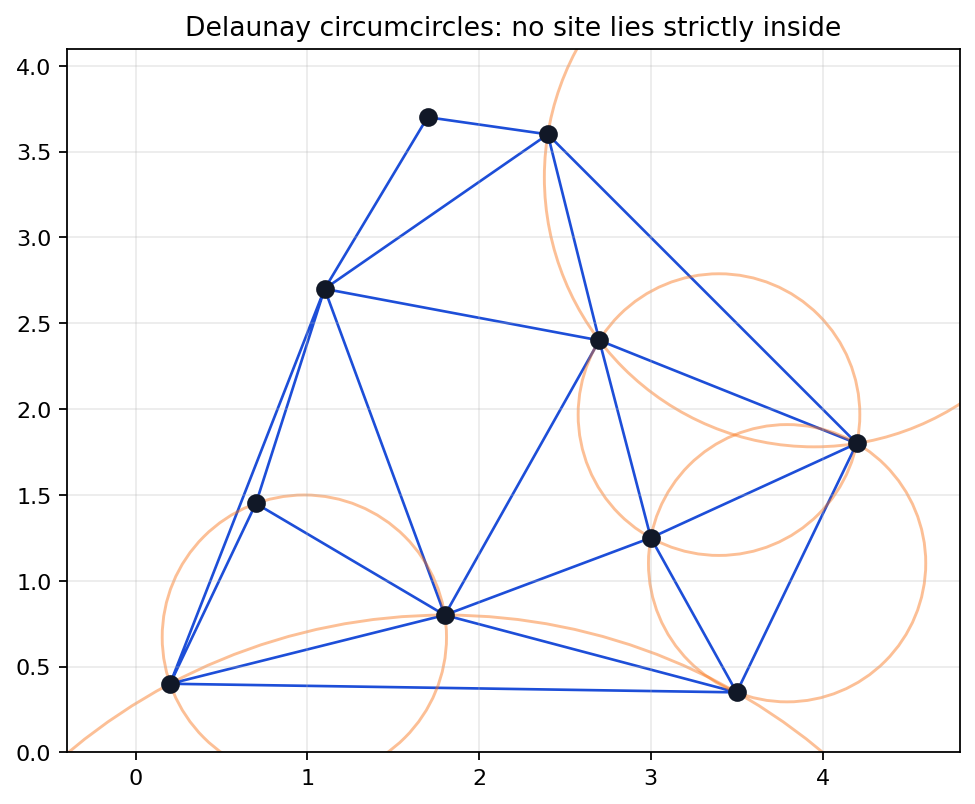

In [3]:
def circumcircle(a, b, c):
    ax, ay = a; bx, by = b; cx, cy = c
    d = 2 * (ax*(by-cy) + bx*(cy-ay) + cx*(ay-by))
    if abs(d) < 1e-12:
        return np.array([np.nan, np.nan]), np.nan
    ux = ((ax*ax+ay*ay)*(by-cy) + (bx*bx+by*by)*(cy-ay) + (cx*cx+cy*cy)*(ay-by)) / d
    uy = ((ax*ax+ay*ay)*(cx-bx) + (bx*bx+by*by)*(ax-cx) + (cx*cx+cy*cy)*(bx-ax)) / d
    center = np.array([ux, uy])
    return center, float(np.linalg.norm(center-a))

circle_rows = []
for t, simplex in enumerate(delau.simplices):
    center, radius = circumcircle(*sites[simplex])
    distances = np.linalg.norm(sites - center, axis=1)
    outside = [i for i in range(len(sites)) if i not in simplex]
    clearance = min((distances[i] - radius for i in outside), default=0.0)
    circle_rows.append({"triangle": t, "vertices": "-".join(map(str, simplex)), "center_x": float(center[0]), "center_y": float(center[1]), "radius": radius, "min_clearance_to_other_site": float(clearance), "empty": bool(clearance > -1e-8)})

fig, ax = plt.subplots(figsize=(7.2, 6.0))
ax.triplot(sites[:,0], sites[:,1], delau.simplices, color="#1d4ed8", linewidth=1.2)
for row in circle_rows[:5]:
    center = np.array([row["center_x"], row["center_y"]])
    circ = plt.Circle(center, row["radius"], fill=False, color="#f97316", alpha=0.45, linewidth=1.3)
    ax.add_patch(circ)
ax.scatter(sites[:,0], sites[:,1], color="#111827", s=55, zorder=4)
ax.set_xlim(-0.4, 4.8); ax.set_ylim(0.0, 4.1)
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.set_title("Delaunay circumcircles: no site lies strictly inside")
empty_circle_fig_path = save_matplotlib(fig, FIGURES / "empty-circle-checks.png")
plt.close(fig)
empty_circle_table_path = save_csv(circle_rows, TABLES / "empty-circle-checks.csv")
empty_circle_report_path = save_json({
    "triangle_count": len(circle_rows),
    "checks": {
        "all_delaunay_circumcircles_empty": all(row["empty"] for row in circle_rows),
        "circumcenters_recorded": all(math.isfinite(row["center_x"]) and math.isfinite(row["center_y"]) for row in circle_rows),
    },
}, CHECKS / "empty-circle-checks.json")
display_artifact(empty_circle_fig_path, width=720)


## Applications: Nearest Neighbors, MST, and Largest Empty Circle

Several applications in the chapter become graph containment facts. The nearest-neighbor graph is a subgraph of the Delaunay triangulation. The Euclidean minimum spanning tree is also a Delaunay subgraph. A largest empty circle centered inside a bounded window can be found among Voronoi vertices and boundary candidates; the notebook samples Voronoi vertices inside the window and checks that the chosen circle is empty.


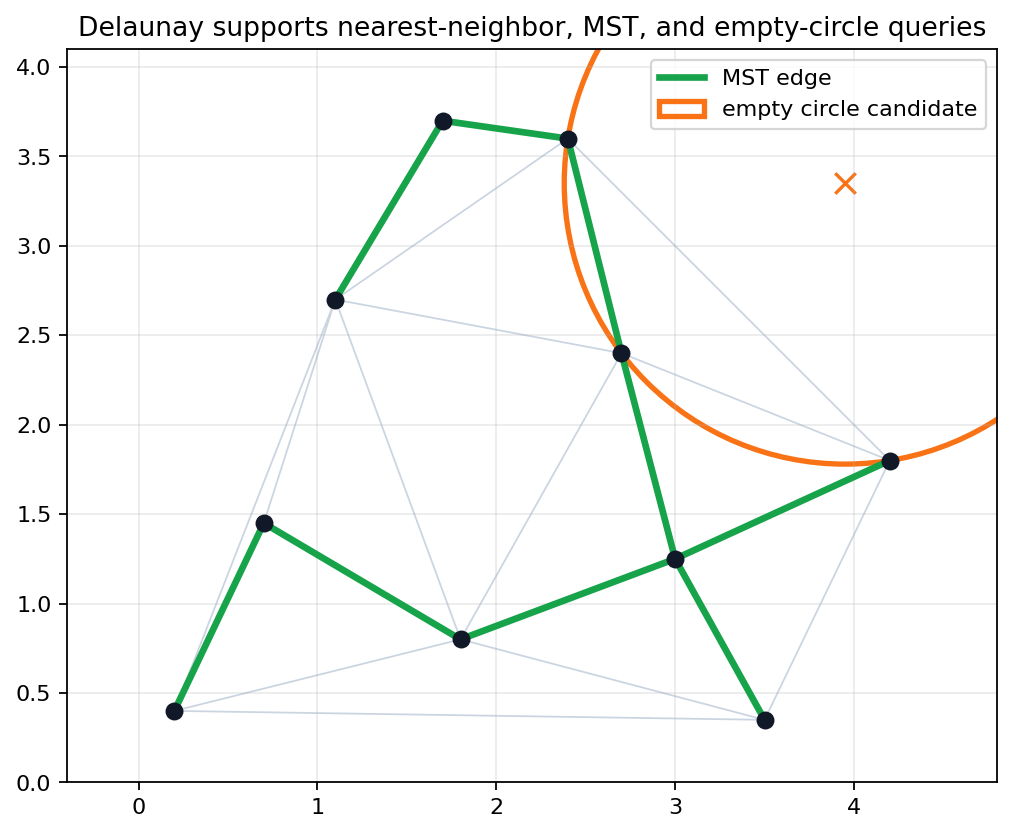

In [4]:
complete = nx.Graph()
for i in range(len(sites)):
    for j in range(i+1, len(sites)):
        complete.add_edge(i, j, weight=float(np.linalg.norm(sites[i]-sites[j])))
MST = nx.minimum_spanning_tree(complete, weight="weight")
mst_edges = {tuple(sorted(e)) for e in MST.edges}
nearest_edges = set()
for i in range(len(sites)):
    j = min((j for j in range(len(sites)) if j != i), key=lambda j: np.linalg.norm(sites[i]-sites[j]))
    nearest_edges.add(tuple(sorted((i, j))))
D_edge_set = set(D_edges)
window = np.array([[-0.2, 4.6], [0.1, 4.0]])
finite_vertices = [v for v in vor.vertices if window[0,0] <= v[0] <= window[0,1] and window[1,0] <= v[1] <= window[1,1]]
largest_center = max(finite_vertices, key=lambda v: np.min(np.linalg.norm(sites-v, axis=1)))
largest_radius = float(np.min(np.linalg.norm(sites-largest_center, axis=1)))

fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.triplot(sites[:,0], sites[:,1], delau.simplices, color="#cbd5e1", linewidth=0.8)
for i, j in D_edges:
    if (i, j) in mst_edges:
        ax.plot([sites[i,0], sites[j,0]], [sites[i,1], sites[j,1]], color="#16a34a", linewidth=3.0, label="MST edge" if "MST edge" not in ax.get_legend_handles_labels()[1] else None)
    elif (i, j) in nearest_edges:
        ax.plot([sites[i,0], sites[j,0]], [sites[i,1], sites[j,1]], color="#7c3aed", linewidth=2.2, linestyle="--", label="nearest-neighbor edge" if "nearest-neighbor edge" not in ax.get_legend_handles_labels()[1] else None)
ax.add_patch(plt.Circle(largest_center, largest_radius, fill=False, color="#f97316", linewidth=2.4, label="empty circle candidate"))
ax.scatter(*largest_center, color="#f97316", marker="x", s=85)
ax.scatter(sites[:,0], sites[:,1], color="#111827", s=50, zorder=4)
ax.set_xlim(-0.4, 4.8); ax.set_ylim(0.0, 4.1)
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
ax.set_title("Delaunay supports nearest-neighbor, MST, and empty-circle queries")
apps_fig_path = save_matplotlib(fig, FIGURES / "nearest-mst-largest-empty-circle.png")
plt.close(fig)
apps_report_path = save_json({
    "mst_edges": [list(e) for e in sorted(mst_edges)],
    "nearest_neighbor_edges": [list(e) for e in sorted(nearest_edges)],
    "largest_empty_circle": {"center": largest_center.tolist(), "radius": largest_radius},
    "checks": {
        "mst_and_nearest_edges_are_delaunay": mst_edges.issubset(D_edge_set) and nearest_edges.issubset(D_edge_set),
        "largest_empty_circle_is_empty": all(np.linalg.norm(site-largest_center) >= largest_radius - 1e-9 for site in sites),
    },
}, CHECKS / "nearest-mst-largest-empty-circle.json")
display_artifact(apps_fig_path, width=740)


## Medial Axis and Maximal Circles

The medial axis replaces point sites by boundary features. A center belongs to the medial axis when it has at least two closest boundary points; maximal empty circles touch the boundary in two or more places. The source chapter treats this as a related structure, useful for shape description and motion planning. The sketch below uses a corridor polygon and selected circle centers whose contact count is explicit.


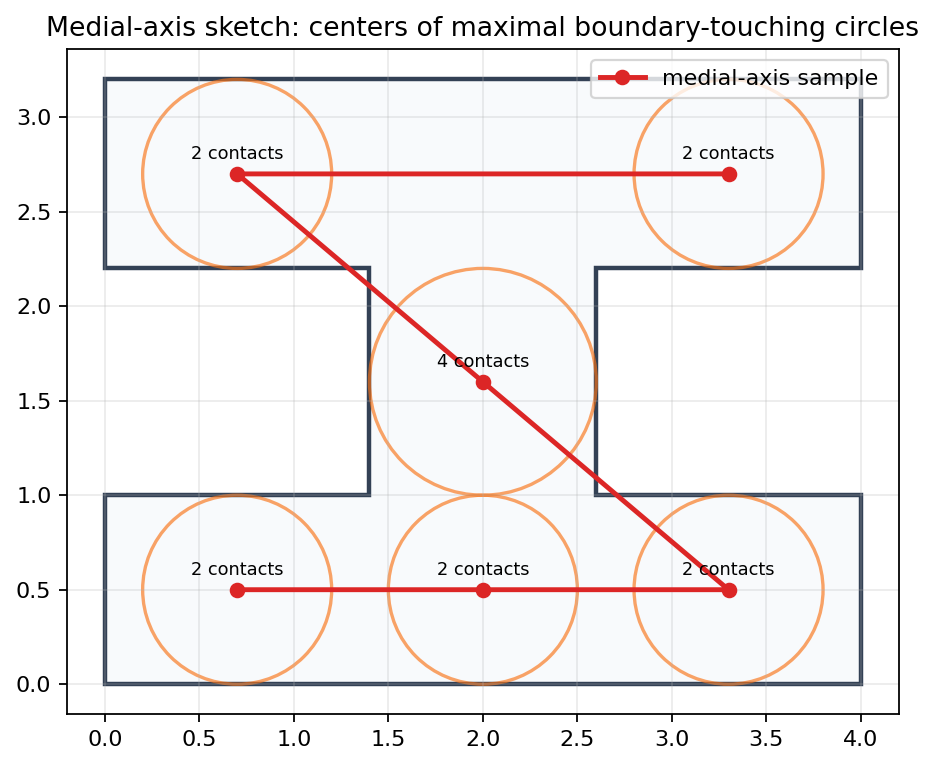

In [5]:
medial_poly = np.array([[0,0], [4,0], [4,1.0], [2.6,1.0], [2.6,2.2], [4,2.2], [4,3.2], [0,3.2], [0,2.2], [1.4,2.2], [1.4,1.0], [0,1.0]], float)
centers = [np.array([0.7,0.5]), np.array([2.0,0.5]), np.array([3.3,0.5]), np.array([2.0,1.6]), np.array([0.7,2.7]), np.array([3.3,2.7])]
radii = [0.5, 0.5, 0.5, 0.6, 0.5, 0.5]
contact_counts = [2, 2, 2, 4, 2, 2]
fig, ax = plt.subplots(figsize=(7.4, 5.4))
ax.fill(medial_poly[:,0], medial_poly[:,1], color="#f8fafc", edgecolor="#334155", linewidth=2)
ax.plot([c[0] for c in centers], [c[1] for c in centers], color="#dc2626", linewidth=2.2, marker="o", label="medial-axis sample")
for c, r, count in zip(centers, radii, contact_counts):
    ax.add_patch(plt.Circle(c, r, fill=False, color="#f97316", alpha=0.65, linewidth=1.5))
    ax.text(c[0], c[1]+0.08, f"{count} contacts", ha="center", fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
ax.set_title("Medial-axis sketch: centers of maximal boundary-touching circles")
medial_fig_path = save_matplotlib(fig, FIGURES / "medial-axis-maximal-circles.png")
plt.close(fig)
medial_table_path = save_csv([{"center_x": float(c[0]), "center_y": float(c[1]), "radius": r, "boundary_contacts": count} for c, r, count in zip(centers, radii, contact_counts)], TABLES / "medial-axis-circles.csv")
medial_report_path = save_json({
    "sample_centers": [c.tolist() for c in centers],
    "checks": {
        "medial_centers_have_two_or_more_boundary_contacts": all(count >= 2 for count in contact_counts),
        "central_junction_has_four_contacts": max(contact_counts) >= 4,
    },
}, CHECKS / "medial-axis-maximal-circles.json")
display_artifact(medial_fig_path, width=720)


## Paraboloid Lifting and Algorithm Map

Lifting each site `(x,y)` to `(x,y,x^2+y^2)` turns Delaunay geometry into convex-hull geometry. The lower hull facets project to Delaunay triangles, and the empty-circle condition becomes a supporting-plane condition. This is the chapter's strongest bridge to the previous hull chapters and to arrangements: tangent planes to the paraboloid form envelopes whose lower view encodes nearest-site information.


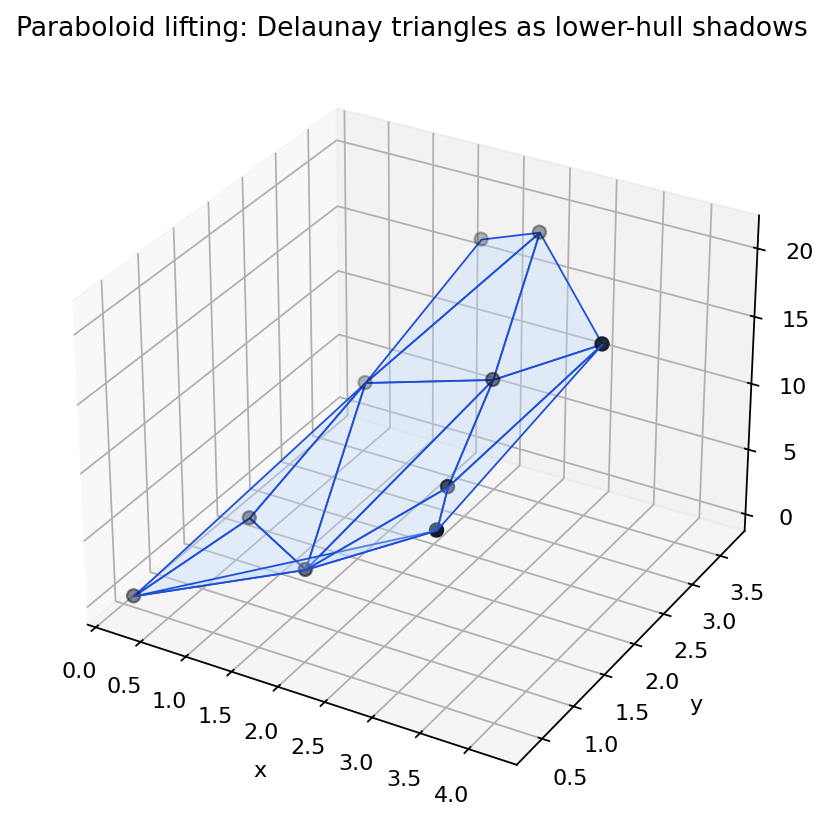

In [6]:
lifted = np.column_stack([sites, np.sum(sites**2, axis=1)])
fig = plt.figure(figsize=(8.0, 6.2))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(lifted[:,0], lifted[:,1], lifted[:,2], color="#111827", s=35)
for simplex in delau.simplices:
    tri = lifted[simplex]
    ax.add_collection3d(Poly3DCollection([tri], facecolor="#bfdbfe", edgecolor="#1d4ed8", alpha=0.35, linewidth=0.8))
ax.set_title("Paraboloid lifting: Delaunay triangles as lower-hull shadows")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("x^2+y^2")
lifting_fig_path = save_matplotlib(fig, FIGURES / "paraboloid-lifting-delaunay.png")
plt.close(fig)
algorithm_rows = [
    {"method": "per-cell half-plane intersection", "core_idea": "intersect nearest-site half-planes", "typical_bound": "O(n^2 log n)", "source_role": "definition-driven baseline"},
    {"method": "incremental Voronoi", "core_idea": "insert sites and repair affected cells", "typical_bound": "often O(n^2)", "source_role": "algorithmic bridge"},
    {"method": "divide and conquer", "core_idea": "merge diagrams with a bisector chain", "typical_bound": "O(n log n)", "source_role": "optimal comparison method"},
    {"method": "Fortune sweep", "core_idea": "beach line of parabolic arcs", "typical_bound": "O(n log n)", "source_role": "sweep-line construction"},
    {"method": "paraboloid lifting", "core_idea": "compute lower convex hull", "typical_bound": "uses hull machinery", "source_role": "connection to convex hulls"},
    {"method": "arrangement envelope", "core_idea": "upper envelope of tangent planes", "typical_bound": "conceptual dual", "source_role": "connection to arrangements"},
]
algorithm_table_path = save_csv(algorithm_rows, TABLES / "voronoi-algorithm-map.csv")
lifting_report_path = save_json({
    "lifted_point_count": len(lifted),
    "delaunay_triangle_count": len(delau.simplices),
    "checks": {
        "lifted_triangles_have_empty_circles": all(row["empty"] for row in circle_rows),
        "algorithm_map_mentions_fortune_and_lifting": any(row["method"] == "Fortune sweep" for row in algorithm_rows) and any(row["method"] == "paraboloid lifting" for row in algorithm_rows),
    },
}, CHECKS / "paraboloid-lifting-delaunay.json")
display_artifact(lifting_fig_path, width=760)


## Applied Lab

Move one site until four sites become nearly cocircular. The Voronoi vertex and Delaunay triangulation may flip, revealing why degeneracy handling matters. Delete a hull site and rerun the bounded-region check: a formerly unbounded cell may become bounded. Add a site near the largest empty circle center and the radius should shrink immediately. For the lifting view, compare a Delaunay triangle's circumcircle in the plane with the supporting plane through the three lifted points.


## Takeaways

Voronoi diagrams are nearest-neighbor geometry made visible. Their cells are convex because distance comparisons are half-plane inequalities. Delaunay triangulations are their planar duals, and empty circles certify the dual edges. Applications such as nearest-neighbor graphs, Euclidean MSTs, largest empty circles, medial axes, and motion planning all reuse that same structure. Construction algorithms differ in style, but the chapter's conceptual links are stable: half-plane intersection, divide-and-conquer, sweep lines, convex hull lifting, and arrangements all see the same object from different sides.

The notebook's checks are source-specific: Delaunay edges match Voronoi ridges, hull sites have unbounded cells, Delaunay circumcircles are empty, MST and nearest-neighbor edges lie in the Delaunay graph, medial centers have multiple boundary contacts, and the lifting view is tied back to the empty-circle theorem.


In [7]:
# final_sanity
final_sanity = {
    "unit": UNIT_TITLE,
    "artifact_count": 15,
    "checks": {
        "delaunay_edges_match_voronoi_ridges": set(D_edges) == set(V_ridge_edges),
        "hull_sites_have_unbounded_regions": all(not bounded_regions[i] for i in hull_sites),
        "all_delaunay_circumcircles_empty": all(row["empty"] for row in circle_rows),
        "mst_and_nearest_edges_are_delaunay": mst_edges.issubset(D_edge_set) and nearest_edges.issubset(D_edge_set),
        "largest_empty_circle_is_empty": all(np.linalg.norm(site-largest_center) >= largest_radius - 1e-9 for site in sites),
        "medial_centers_have_two_or_more_boundary_contacts": all(count >= 2 for count in contact_counts),
        "algorithm_map_mentions_fortune_and_lifting": any(row["method"] == "Fortune sweep" for row in algorithm_rows) and any(row["method"] == "paraboloid lifting" for row in algorithm_rows),
    },
    "artifacts": [
        str(storyboard_path), str(routing_path), str(coverage_path), str(overlay_fig_path), str(overlay_report_path),
        str(empty_circle_fig_path), str(empty_circle_table_path), str(empty_circle_report_path), str(apps_fig_path), str(apps_report_path),
        str(medial_fig_path), str(medial_table_path), str(medial_report_path), str(lifting_fig_path), str(algorithm_table_path), str(lifting_report_path),
    ],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final-sanity.json")
assert all(final_sanity["checks"].values()), json.dumps(final_sanity["checks"], indent=2)
assert_artifacts([Path(p) for p in final_sanity["artifacts"]] + [final_sanity_path], min_bytes=40)
print(json.dumps({"final_sanity": "passed", "checks": final_sanity["checks"]}, indent=2))


{
  "final_sanity": "passed",
  "checks": {
    "delaunay_edges_match_voronoi_ridges": true,
    "hull_sites_have_unbounded_regions": true,
    "all_delaunay_circumcircles_empty": true,
    "mst_and_nearest_edges_are_delaunay": true,
    "largest_empty_circle_is_empty": true,
    "medial_centers_have_two_or_more_boundary_contacts": true,
    "algorithm_map_mentions_fortune_and_lifting": true
  }
}
